In [8]:
library(ape)
library(ggtree)
library(ggplot2)
library(patchwork)
# set input and output paths

indir <- "../../results/ml_iqtree/"
outdir <- file.path(indir, "tree_plots")
dir.create(outdir, recursive = TRUE, showWarnings = FALSE)

# color tips by biological lineage / comparison group
lineage_df <- data.frame(
    label = c("Bg", "Ee", "Bb", "Pk", "Ip"),
    lineage = c(
        "South American electric fishes",
        "South American electric fishes",
        "African weakly electric fishes",
        "African weakly electric fishes",
        "Ictaluridae outgroup"
    )
)

lineage_palette <- c(
    "South American electric fishes" = "#1b9e77",
    "African weakly electric fishes" = "#d95f02",
    "Ictaluridae outgroup" = "#7570b3"
)

lineage_shapes <- c(
    "South American electric fishes" = 21,
    "African weakly electric fishes" = 22,
    "Ictaluridae outgroup" = 24
)

In [9]:
## function to root tree using outgroup and plot
plot_iqtree_tree <- function(tree_file, outfile_prefix, plot_title) {
    cat("Reading tree:", tree_file, "
")

    tree <- read.tree(tree_file)
    cat("Before rooting:
")
    print(tree)

    # IQ-TREE used -o Ip, but ape still reads the tree as unrooted.
    tree_rooted <- root(tree, outgroup = "Ip", resolve.root = FALSE)
    tree_rooted <- ladderize(tree_rooted)

    cat("After rooting with Ip:
")
    print(tree_rooted)

    p <- ggtree(tree_rooted, layout = "rectangular", size = 0.9) %<+% lineage_df +
        geom_tippoint( aes(color = lineage, shape = lineage), size = 3, fill = "white", stroke = 1.1 ) +
        geom_tiplab( aes(color = lineage), size = 4, fontface = "bold", offset = 0.01, show.legend = FALSE ) +
        geom_label2( aes(subset = !isTip & !is.na(label) & label != "", label = label), hjust = -0.15, vjust = -0.35, size = 3, label.size = 0.2, fill = "white",  color = "gray25"  ) +
        scale_color_manual(values = lineage_palette, name = "Lineage / group") +
        scale_shape_manual(values = lineage_shapes, name = "Lineage / group") +
        ggtitle(plot_title) +
        theme_tree2() +
        theme( plot.title = element_text(hjust = 0.5, face = "bold", size = 14), legend.position = "right", legend.title = element_text(face = "bold") )

    print(p)

    pdf_file <- paste0(outfile_prefix, ".pdf")
    png_file <- paste0(outfile_prefix, ".png")

    ggsave(pdf_file, plot = p, width = 8, height = 5)
    ggsave(png_file, plot = p, width = 8, height = 5, dpi = 300)

    cat("
")
    return(p)
}

Reading tree: ../../results/ml_iqtree//aa_partitioned/aa_partitioned.treefile 
Before rooting:

Phylogenetic tree with 5 tips and 3 internal nodes.

Tip labels:
  Bg, Ee, Bb, Pk, Ip
Node labels:
  , 100/100, 100/100

Unrooted; includes branch length(s).
After rooting with Ip:

Phylogenetic tree with 5 tips and 3 internal nodes.

Tip labels:
  Bg, Ee, Bb, Pk, Ip
Node labels:
  , 100/100, 100/100

Unrooted; includes branch length(s).


Warning message in geom_label2(aes(subset = !isTip & !is.na(label) & label != "", :
“Ignoring unknown parameters: `label.size`”


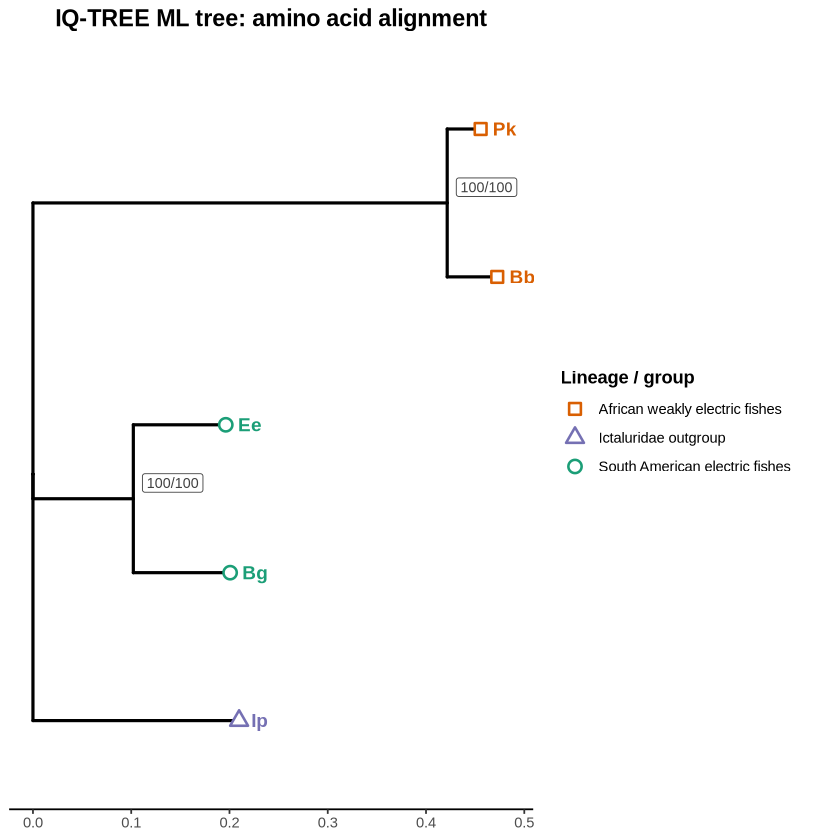

In [10]:
# plot AA tree
p_aa <- plot_iqtree_tree(
	tree_file = file.path(indir, "aa_partitioned", "aa_partitioned.treefile"),
	outfile_prefix = file.path(outdir, "aa_partitioned_iqtree_rooted"),
	plot_title = "IQ-TREE ML tree: amino acid alignment"
)

Reading tree: ../../results/ml_iqtree//nt_partitioned/nt_partitioned.treefile 
Before rooting:

Phylogenetic tree with 5 tips and 3 internal nodes.

Tip labels:
  Bg, Ee, Bb, Pk, Ip
Node labels:
  , 100/100, 100/100

Unrooted; includes branch length(s).
After rooting with Ip:

Phylogenetic tree with 5 tips and 3 internal nodes.

Tip labels:
  Bg, Ee, Bb, Pk, Ip
Node labels:
  , 100/100, 100/100

Unrooted; includes branch length(s).


Warning message in geom_label2(aes(subset = !isTip & !is.na(label) & label != "", :
“Ignoring unknown parameters: `label.size`”


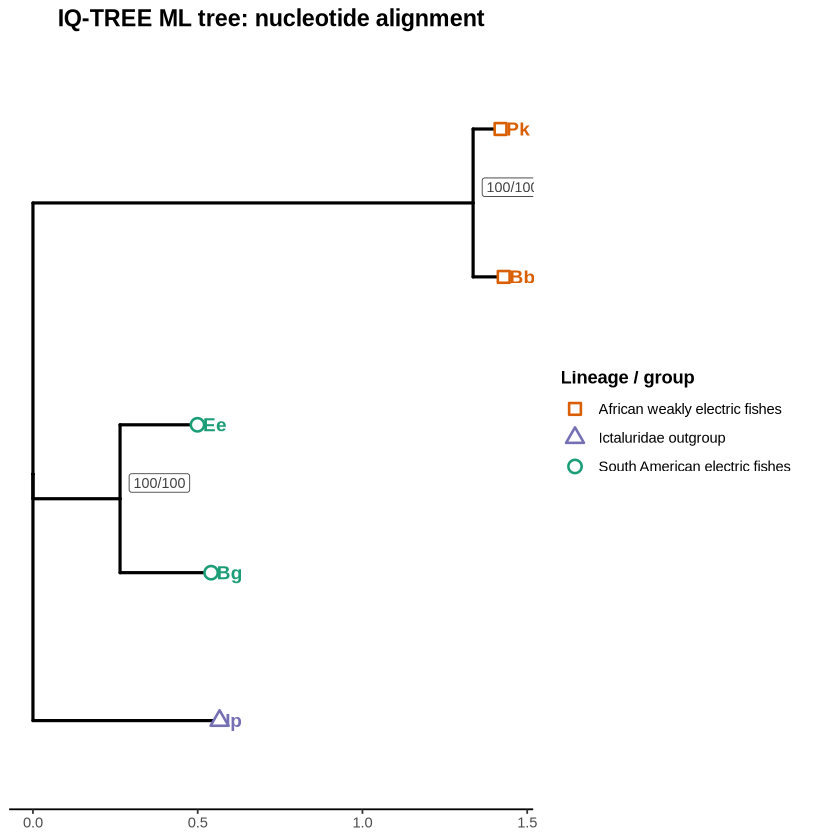

In [11]:
# plot NT tree
p_nt <- plot_iqtree_tree(
	tree_file = file.path(indir, "nt_partitioned", "nt_partitioned.treefile"),
	outfile_prefix = file.path(outdir, "nt_partitioned_iqtree_rooted"),
	plot_title = "IQ-TREE ML tree: nucleotide alignment"
)



In [12]:
# compare the two trees side by side
combined_plot <- p_aa + p_nt + plot_layout(ncol = 2)
ggsave( filename = file.path(outdir, "comparison_aa_nt_iqtree_rooted.pdf"), plot = combined_plot, width = 16, height = 5)
ggsave(filename = file.path(outdir, "comparison_aa_nt_iqtree_rooted.png"), plot = combined_plot, width = 16, height = 5, dpi = 300 )

cat("Wrote combined AA/NT comparison plot\n")

Wrote combined AA/NT comparison plot
